In [2]:
import pandas as pd
import tensorflow as tf
import tensorflow_privacy as tfp
from tensorflow.keras.layers import Input, Dense, Embedding, Flatten, Concatenate
from tensorflow.keras.models import Model
import shap
import numpy as np
import matplotlib.pyplot as plt

c:\Users\slava\OneDrive\Рабочий стол\PyDissertation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Указываем пути к файлам
train_path = r'C:\Users\slava\OneDrive\Рабочий стол\PyDissertation\Criteo_x1\train.csv'
test_path  = r'C:\Users\slava\OneDrive\Рабочий стол\PyDissertation\Criteo_x1\test.csv'
valid_path = r'C:\Users\slava\OneDrive\Рабочий стол\PyDissertation\Criteo_x1\valid.csv'

In [ ]:
# Загружаем данные в датафреймы
df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)
df_valid = pd.read_csv(valid_path)


In [ ]:
# Проверяем, что всё загрузилось успешно
print("Размер тренировочной выборки (строки, колонки):", df_train.shape)
print("Размер тестовой выборки:", df_test.shape)
print("Размер валидационной выборки:", df_valid.shape)

# Снимаем ограничение на количество отображаемых колонок
pd.set_option('display.max_columns', None)

# Смотрим первые 5 строк тренировочного датасета
df_train.head()

Размер тренировочной выборки (строки, колонки): (33003326, 40)
Размер тестовой выборки: (4587167, 40)
Размер валидационной выборки: (8250124, 40)


,label,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
0,0,0.05,0.006633,0.05,0.00,0.021594,0.008,0.15,0.04,0.362,0.1,0.2,0.0,0.04,15,1484,2032,421036,664216,664522,666759,676735,677367,677738,733335,737432,1148460,1150514,1150756,1184372,1528982,1529013,1533925,1536019,1556876,1934144,1934164,1936312,2022803,2024738
1,0,0.10,0.004975,0.44,0.02,0.001594,0.016,0.02,0.04,0.008,0.1,0.1,0.0,0.08,15,1490,2042,415618,664216,664524,666676,676733,677367,678156,732765,737443,1147992,1150512,1150579,1163048,1528983,1529008,1533925,1536020,1536034,1934144,1934164,1934195,2022803,2022906
2,0,0.10,0.004975,0.01,0.28,0.011984,0.178,0.04,0.04,0.490,0.1,0.3,0.3,0.90,37,1522,2034,415607,664216,664522,664925,676733,677367,677371,732554,737435,1147748,1150513,1151267,1163039,1528988,1529304,1533924,1536018,1536025,1934145,1934164,1934181,2022801,2022897
3,0,0.00,1.000000,0.00,0.00,0.068625,0.000,0.00,0.00,0.000,0.0,0.0,0.0,0.00,15,1487,2032,415832,664216,664524,664614,676733,677367,677372,732086,737432,1147333,1150513,1150556,1163036,1528989,1529022,1533924,1536018,1536022,1934144,1934164,1934185,2022801,2022897
4,0,0.15,0.003317,0.00,0.00,0.000031,0.000,0.03,0.00,0.000,0.1,0.1,0.0,0.00,17,1504,2032,415612,664216,664525,665982,676733,677367,678333,732804,737472,1148026,1150514,1150892,1163052,1528989,1529288,1533924,1536018,1536038,1934144,1934163,1934180,2022801,2022897


In [6]:
df_test.head()

,label,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
0,1,0.0,0.008292,0.11,0.10,0.160344,0.068,0.02,0.08,0.010,0.0,0.1,0.0,0.10,18,1479,2032,420661,664216,664521,664814,676748,677367,677662,732093,737432,1147338,1150514,1150550,1163036,1528983,1528994,1534050,1536021,1536022,1934144,1934163,1934311,2022806,2024736
1,1,0.0,0.134328,0.02,0.30,0.067359,0.170,0.04,0.36,0.460,0.0,0.3,0.0,0.30,15,1669,168320,530790,664217,664526,664929,676733,677367,677606,732155,910458,1147414,1150512,1151620,1318886,1528982,1529471,1533924,1536018,1707732,1934144,1934163,1935911,2022801,2022897
2,0,0.0,0.003317,0.00,0.00,0.077438,0.000,0.00,0.74,0.194,0.0,0.0,0.0,0.00,18,1508,2033,415607,664216,664524,665408,676733,677367,677371,733145,737433,1147419,1150518,1150585,1163037,1528986,1529049,1533924,1536018,1536023,1934144,1934169,1934181,2022801,2022897
3,1,1.0,0.533997,0.00,0.08,0.000078,0.008,0.89,0.80,0.176,0.3,0.4,1.0,0.08,14,1486,2208,415748,664216,664523,664568,676733,677367,677567,732126,737610,1147380,1150512,1150557,1163164,1528988,1529017,1533924,1536018,1536209,1934144,1934163,1934312,2022801,2022897
4,0,0.0,0.097844,0.02,0.00,0.000000,0.000,0.00,0.00,0.002,0.0,0.0,0.0,0.00,16,1497,2034,415607,664216,664523,664579,676734,677368,677371,732150,737435,1147335,1150512,1150612,1163039,1528990,1529030,1533924,1536018,1536025,1934144,1934167,1934181,2022801,2022897


In [7]:
df_valid.head()

,label,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15,C16,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
0,0,0.00,0.006633,0.02,0.00,0.049500,0.000,0.00,0.02,0.004,0.0,0.0,0.0,0.00,30,1540,2082,415670,664218,664524,674803,676733,677367,677371,732721,737488,1147952,1150513,1150719,1163099,1528986,1529077,1533924,1536018,1536080,1934144,1934171,1934205,2022801,2022897
1,0,0.00,0.077944,0.04,0.16,0.297031,0.498,0.28,0.62,0.282,0.0,0.1,0.0,0.16,14,1496,2033,415607,664216,664522,666035,676733,677367,685051,733012,737433,1148010,1150512,1150764,1163037,1528982,1529141,1533924,1536018,1536023,1934144,1934163,1934181,2022801,2022897
2,0,0.00,0.014925,0.06,0.12,0.006578,0.218,0.01,0.14,0.214,0.0,0.1,0.0,0.12,14,1901,2032,415606,664217,664521,667284,676733,677367,677371,733187,737432,1148336,1150513,1152548,1163036,1528984,1530174,1533924,1536018,1536022,1934144,1934163,1934178,2022801,2022897
3,1,0.00,0.003317,0.00,0.00,0.022891,0.000,0.17,0.00,0.008,0.0,0.4,0.0,0.00,26,1475,2032,415614,664216,664524,664543,676735,677367,677391,732085,737432,1147332,1150513,1151648,1163043,1528982,1529023,1533924,1536018,1536029,1934144,1934163,1934180,2022801,2022897
4,0,0.35,0.174129,0.00,0.06,0.012188,0.030,0.07,0.30,0.030,0.1,0.1,0.0,0.06,40,1626,4768,419345,664217,664525,665930,676733,677367,678669,732871,740240,1147913,1150522,1157583,1166229,1528982,1531458,1533924,1536018,1538936,1934144,1934172,1936323,2022801,2022897


In [ ]:
# 2. ДЕЛАЕМ ВЫБОРКУ (16 ГБ RAM)
SAMPLE_SIZE = 500000 
df_train_sample = df_train.sample(n=SAMPLE_SIZE, random_state=42)
df_test_sample = df_test.sample(n=int(SAMPLE_SIZE * 0.2), random_state=42)
df_valid_sample = df_valid.sample(n=int(SAMPLE_SIZE * 0.2), random_state=42)

In [9]:
# Определяем списки колонок
target = 'label'
dense_features = [f'I{i}' for i in range(1, 14)] # Числовые (I1 ... I13)
sparse_features = [f'C{i}' for i in range(1, 27)] # Категориальные (C1 ... C26)

In [ ]:
# ПОДГОТОВКА ВХОДОВ ДЛЯ НЕЙРОСЕТИ

# Вход для числовых (Dense) признаков
dense_inputs = Input(shape=(len(dense_features),), name='dense_inputs')

sparse_inputs = {}
sparse_embeddings = []

print("Создаем слои Embedding для категорий...")
for feat in sparse_features:
    # Ищем максимальный индекс категории, чтобы задать размер словаря
    # Ищем по всем таблицам, чтобы избежать ошибки OutOfBounds
    vocab_size = int(max(df_train[feat].max(), df_valid[feat].max(), df_test[feat].max()) + 1)
    
    # Входной слой для конкретной категории
    inp = Input(shape=(1,), name=feat)
    sparse_inputs[feat] = inp
    
    # Embedding-слой (сжимаем категорию в вектор из 8 чисел)
    emb = Embedding(input_dim=vocab_size, output_dim=8)(inp)
    sparse_embeddings.append(Flatten()(emb))


Создаем слои Embedding для категорий...


In [ ]:
# WIDE ЧАСТЬ (Запоминание)

wide_output = dense_inputs

In [ ]:
# DEEP ЧАСТЬ (Обобщение)

# Объединяем эмбеддинги и числовые данные
deep_concat = Concatenate()(sparse_embeddings + [dense_inputs])
deep_layer = Dense(128, activation='relu')(deep_concat)
deep_layer = Dense(64, activation='relu')(deep_layer)
deep_layer = Dense(32, activation='relu')(deep_layer)

In [ ]:
# СЛИЯНИЕ WIDE И DEEP

final_concat = Concatenate()([wide_output, deep_layer])

In [14]:
# Выходной слой (сигмоида для предсказания вероятности клика от 0 до 1)
output = Dense(1, activation='sigmoid', name='output')(final_concat)

In [ ]:
# СБОРКА И КОМПИЛЯЦИЯ МОДЕЛИ
model_inputs = [dense_inputs] + list(sparse_inputs.values())
model = Model(inputs=model_inputs, outputs=output)

In [16]:
# Собираем модель. Используем базовый Adam (Differential Privacy добавим позже для сравнения)
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['AUC'])

print("Архитектура Wide & Deep успешно создана!")
model.summary()

Архитектура Wide & Deep успешно создана!
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 C1 (InputLayer)             [(None, 1)]                  0         []                            
                                                                                                  
 C2 (InputLayer)             [(None, 1)]                  0         []                            
                                                                                                  
 C3 (InputLayer)             [(None, 1)]                  0         []                            
                                                                                                  
 C4 (InputLayer)             [(None, 1)]                  0         []                            
                                                     

In [ ]:
# ПОДГОТОВКА И ОБУЧЕНИЕ

# 1. Новая функция для подготовки данных (использует словарь и легкие типы данных)
def get_keras_data_safe(df, dense_cols, sparse_cols):
    X = {}
    # Числовые признаки принудительно делаем float32
    X['dense_inputs'] = df[dense_cols].values.astype(np.float32)
    
    # Категориальные признаки принудительно делаем int32
    for col in sparse_cols:
        X[col] = df[col].values.astype(np.int32)
    return X

print("Упаковываем данные (в безопасном формате)...")
X_train = get_keras_data_safe(df_train_sample, dense_features, sparse_features)
y_train = df_train_sample[target].values.astype(np.float32) # Target тоже float32

X_valid = get_keras_data_safe(df_valid_sample, dense_features, sparse_features)
y_valid = df_valid_sample[target].values.astype(np.float32)

print("Данные готовы. Начинаем обучение базовой модели (Baseline)...")

Упаковываем данные (в безопасном формате)...
Данные готовы. Начинаем обучение базовой модели (Baseline)...


In [ ]:
# ЗАПУСК ОБУЧЕНИЯ (model.fit)
# Используем batch_size=1024, чтобы обучение шло быстрее на процессоре
history = model.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_valid, y_valid),
    batch_size=1024, 
    epochs=3, 
    verbose=1
)

Epoch 1/3

489/489 [==============================] - 996s 2s/step - loss: 0.4910 - auc: 0.7478 - val_loss: 0.4737 - val_auc: 0.7728
Epoch 2/3
489/489 [==============================] - 990s 2s/step - loss: 0.4342 - auc: 0.8187 - val_loss: 0.4865 - val_auc: 0.7622
Epoch 3/3
489/489 [==============================] - 993s 2s/step - loss: 0.3730 - auc: 0.8716 - val_loss: 0.5271 - val_auc: 0.7411


In [ ]:
# ОЦЕНКА РЕЗУЛЬТАТОВ НА ТЕСТОВОЙ ВЫБОРКЕ

print("\n--- Оценка на тестовой выборке ---")
X_test = get_keras_data_safe(df_test_sample, dense_features, sparse_features)
y_test = df_test_sample[target].values.astype(np.float32)

test_loss, test_auc = model.evaluate(X_test, y_test, batch_size=1024)
print(f"Базовый LogLoss: {test_loss:.4f}")
print(f"Базовый AUC: {test_auc:.4f}")


--- Оценка на тестовой выборке ---
98/98 [==============================] - 0s 3ms/step - loss: 0.5259 - auc: 0.7416
Базовый LogLoss: 0.5259
Базовый AUC: 0.7416


In [ ]:
# Функция-обертка (SHAP не понимает слоистые нейросети, поэтому мы переводим данные в плоскую таблицу и обратно)
def predict_wrapper(X_matrix):
    # Разделяем единую матрицу обратно на [Числовые, Категория_1, Категория_2, ... Категория_26]
    X_list = [X_matrix[:, :13]] # Первые 13 колонок - это Dense (I1-I13)
    for i in range(26):
        X_list.append(X_matrix[:, 13 + i]) # Остальные - это Sparse (C1-C26)
    
    # Делаем предсказание и возвращаем одномерный массив вероятностей
    return model.predict(X_list, verbose=0).flatten()


In [ ]:
# Подготовка данных для SHAP
# Склеиваем наши X_train и X_test списки в плоские 2D-матрицы
X_train_flat = np.column_stack(X_train)
X_test_flat = np.column_stack(X_test)

# SHAP требует очень много вычислений. 
# Для "фона" (базовых значений) берем 50 случайных пользователей
background = shap.sample(X_train_flat, 50)

# Будем объяснять предсказания для 10 тестовых пользователей
users_to_explain = X_test_flat[:10]
feature_names = dense_features + sparse_features # Имена всех 39 колонок

In [ ]:
# Склеиваем данные из словаря в плоскую матрицу (N, 39)
# Берем матрицу (N, 13) и добавляем к ней 26 массивов (N, 1)
train_arrays = [X_train['dense_inputs']] + [X_train[col] for col in sparse_features]
X_train_flat = np.column_stack(train_arrays)

test_arrays = [X_test['dense_inputs']] + [X_test[col] for col in sparse_features]
X_test_flat = np.column_stack(test_arrays)

# Новая функция-обертка: переводит плоскую матрицу обратно в СЛОВАРЬ для Keras
def predict_wrapper(X_matrix):
    X_dict = {}
    # Возвращаем 13 колонок на место
    X_dict['dense_inputs'] = X_matrix[:, :13] 
    
    # Возвращаем 26 категорий на их места
    for i, col in enumerate(sparse_features):
        X_dict[col] = X_matrix[:, 13 + i]
        
    return model.predict(X_dict, verbose=0).flatten()

# Инициализация SHAP
# Для "фона" берем 50 случайных пользователей
background = shap.sample(X_train_flat, 50)
# Объясняем предсказания для 10 тестовых пользователей
users_to_explain = X_test_flat[:10]
feature_names = dense_features + sparse_features # Имена всех 39 колонок

In [ ]:
# Инициализация KernelExplainer (Универсальный объяснитель)
print("Запускаем ядро SHAP... (это может занять 1-2 минуты)")
explainer = shap.KernelExplainer(predict_wrapper, background)

# Вычисляем важность признаков (Shapley values)
shap_values = explainer.shap_values(users_to_explain)

Запускаем ядро SHAP... (это может занять 1-2 минуты)


100%|██████████| 10/10 [00:49<00:00,  4.90s/it]



--- ГРАФИК 1: Глобальная важность признаков (Summary Plot) ---


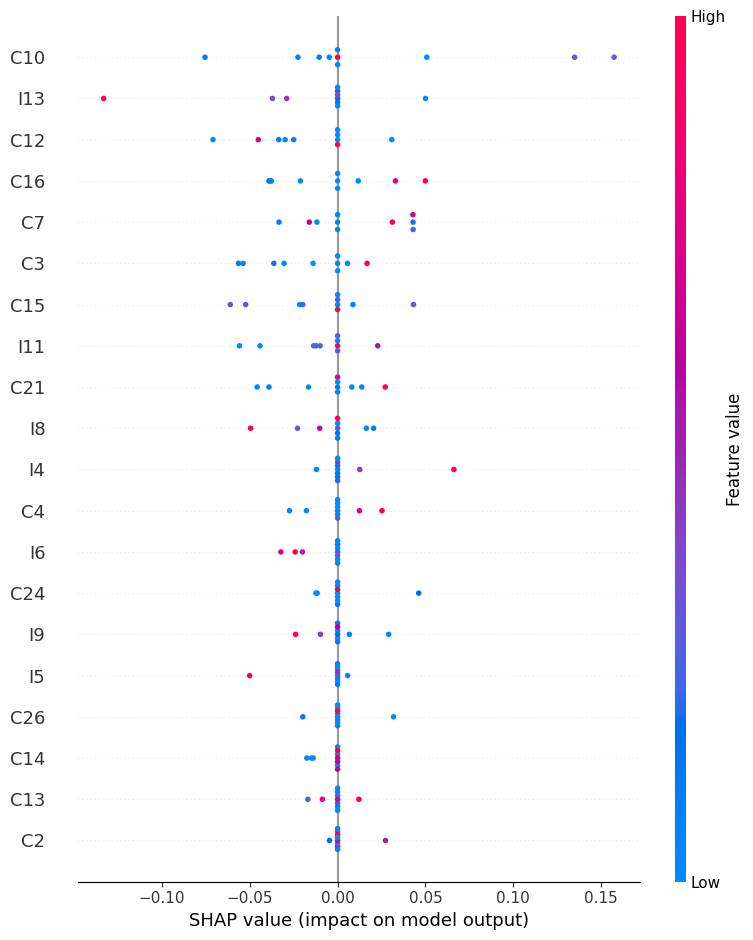

In [ ]:
# ВИЗУАЛИЗАЦИЯ
print("\n--- ГРАФИК 1: Глобальная важность признаков (Summary Plot) ---")
shap.summary_plot(shap_values, users_to_explain, feature_names=feature_names)

In [ ]:
# Клонируем архитектуру, чтобы начать обучение с нуля (честное сравнение)
dp_model = tf.keras.models.clone_model(model)

# Настраиваем "Приватный" Оптимизатор
# l2_norm_clip - обрезает слишком сильные влияния одного пользователя
# noise_multiplier - уровень "шума", который мы добавляем для анонимности
dp_optimizer = tfp.DPKerasAdamOptimizer(
    l2_norm_clip=1.0,
    noise_multiplier=0.1, 
    num_microbatches=1,
    learning_rate=0.001
)

# Для DP-оптимизаторов нужно отключить автоматическое усреднение ошибки
loss = tf.keras.losses.BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)

dp_model.compile(optimizer=dp_optimizer, loss=loss, metrics=['AUC'])

print("Запускаем приватное обучение (DP-Training)...")

# ОБУЧЕНИЕ
dp_history = dp_model.fit(
    x=X_train, y=y_train,
    validation_data=(X_valid, y_valid),
    batch_size=1024, 
    epochs=3, 
    verbose=1
)

# ОЦЕНКА PRIVACY-TRADE-OFF
print("\n--- СРАВНЕНИЕ РЕЗУЛЬТАТОВ ---")
dp_test_loss, dp_test_auc = dp_model.evaluate(X_test, y_test, batch_size=1024)

print(f"Базовый AUC (без защиты): {test_auc:.4f}")
print(f"Приватный AUC (DP):       {dp_test_auc:.4f}")
print(f"Падение точности составило: {(test_auc - dp_test_auc):.4f}")

Запускаем приватное обучение (DP-Training)...
Epoch 1/3
489/489 [==============================] - 983s 2s/step - loss: 0.5887 - auc: 0.5472 - val_loss: 0.5518 - val_auc: 0.6572
Epoch 2/3
489/489 [==============================] - 979s 2s/step - loss: 0.5460 - auc: 0.6682 - val_loss: 0.5400 - val_auc: 0.6791
Epoch 3/3
489/489 [==============================] - 986s 2s/step - loss: 0.5371 - auc: 0.6796 - val_loss: 0.5338 - val_auc: 0.6850

--- СРАВНЕНИЕ РЕЗУЛЬТАТОВ ---
98/98 [==============================] - 0s 3ms/step - loss: 0.5343 - auc: 0.6836
Базовый AUC (без защиты): 0.7416
Приватный AUC (DP):       0.6836
Падение точности составило: 0.0580
